In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, \
                  array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import seaborn as sns
import scipy.cluster.hierarchy
from scipy.spatial.distance import squareform
import sklearn
from sklearn.decomposition import PCA
import itertools
import mdtraj as md
from __future__ import print_function

In [2]:
pdb='/data/Jayde/Rega/Apo/production2us.pbcstruc.gro'
trajectory='/data/Jayde/Rega/Apo/production2us.pbctraj.xtc'
outdir='/data/Jayde/Rega/Apo/HBond_Analysis/'

if not os.path.exists('outdir'):
    os.makedirs('outdir')
    
print("outdir:",outdir)
print("pdb:",pdb)
print("trajectory:",trajectory)

outdir: /data/Jayde/Rega/Apo/HBond_Analysis/
pdb: /data/Jayde/Rega/Apo/production2us.pbcstruc.gro
trajectory: /data/Jayde/Rega/Apo/production2us.pbctraj.xtc


In [3]:
trj = md.load(trajectory, top=pdb,stride=1)
trj.center_coordinates()
top = trj.topology
first_frame = 0
last_frame = trj.n_frames
n_frames=trj.n_frames

In [4]:
nres=[]
for res in trj.topology.residues: nres.append(res.resSeq)
sequence=(' %s' % [residue for residue in trj.topology.residues])
resname=(' %s' % [residue.name for residue in trj.topology.residues])
resindex=(' %s' % [residue.index for residue in trj.topology.residues])
res_num=(' %s' % [residue.resSeq  for residue in trj.topology.residues])

print("** SYSTEM INFO **\n")
print("Number of atoms: %d\n" % trj.n_atoms)
print("Number of residues: %d\n" % len(set(nres)))
print("Number of frames: %d\n" % trj.n_frames)
print("Starting frame: %d\n" % first_frame)
print("Last frame: %d\n" % last_frame)
print("sequence: %s\n" % sequence)
print("residue names: %s\n" % resname)
print("residue number: %s\n" % res_num)
print("residue index: %s\n" % resindex)


** SYSTEM INFO **

Number of atoms: 53156

Number of residues: 12501

Number of frames: 21001

Starting frame: 0

Last frame: 21001

sequence:  [ASN21, ASN22, MET23, LEU24, VAL25, LEU26, LYS27, LYS28, ILE29, ARG30, PHE31, TYR32, ASN33, CYS34, ALA35, ILE36, ILE37, HIS38, LEU39, ARG40, ASP41, ALA42, GLN43, LEU44, LEU45, ILE46, ARG47, THR48, LYS49, ASP50, GLY51, GLN52, THR53, LEU54, ASN55, ILE56, PRO57, PRO58, GLU59, SER60, LEU61, CYS62, TYR63, VAL64, GLU65, LYS66, ASN67, THR68, VAL69, MET70, ASP71, VAL72, ALA73, LEU74, LYS75, VAL76, LEU77, GLY78, SER79, GLY80, VAL81, PRO82, TYR83, GLU84, VAL85, TYR86, HIS87, VAL88, ASP89, SER90, ASP91, VAL92, LEU93, ARG94, CYS95, ILE96, CYS97, LYS98, VAL99, MET100, GLU101, PRO102, LEU103, LEU104, LEU105, ASP106, PRO107, GLN108, ARG109, VAL110, ASN111, HIS112, THR113, ARG114, ARG115, LYS116, ILE117, PHE118, THR119, CYS120, ALA121, VAL122, ASP123, GLU124, THR125, ASP126, THR127, ARG128, ILE129, PHE130, LYS131, ARG132, LEU133, THR134, GLY135, SER136, ASN137

In [5]:
residue_num=[]
for res in top.residues: 
    residue_num.append(res.resSeq)
residue_id=np.asarray(residue_num)
residue_id

array([   21,    22,    23, ..., 12519, 12520, 12521], shape=(12501,))

In [6]:
protein_indices = trj.topology.select('protein')
traj_protein = trj.atom_slice(protein_indices)
# del trj

In [7]:
#Use DSSP to calculate the secondary structure definition
#https://mdtraj.org/1.9.4/api/generated/mdtraj.compute_dssp.html
dssp=md.compute_dssp(traj_protein,simplified=True)
dssp

array([['C', 'C', 'C', ..., 'H', 'C', 'C'],
       ['C', 'C', 'C', ..., 'H', 'C', 'C'],
       ['C', 'C', 'C', ..., 'C', 'C', 'C'],
       ...,
       ['C', 'E', 'E', ..., 'C', 'C', 'C'],
       ['C', 'E', 'E', ..., 'C', 'C', 'C'],
       ['C', 'E', 'E', ..., 'C', 'C', 'C']],
      shape=(21001, 254), dtype='<U2')

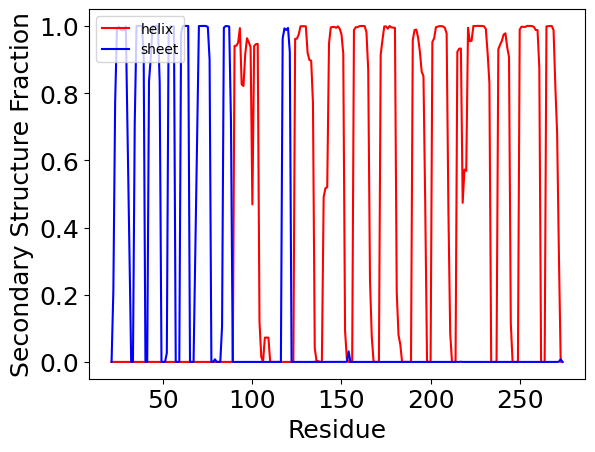

In [8]:
dssp=md.compute_dssp(traj_protein,simplified=True)

residue_num=[]
for res in traj_protein.topology.residues: 
    residue_num.append(res.resSeq)
residue_id=np.asarray(residue_num)
residue_id

def dssp_convert(dssp):
 dsspH=np.copy(dssp)
 dsspE=np.copy(dssp)
 dsspH[dsspH=='H']=1                                                                                      
 dsspH[dsspH=='E']=0                                                                                      
 dsspH[dsspH=='C']=0                                                                                      
 dsspH[dsspH=='NA']=0 
 dsspH=dsspH.astype(int)
 TotalH=np.sum(dsspH,axis=1) 
 Hprop=np.sum(dsspH,axis=0).astype(float)/len(dsspE) 

 dsspE[dsspE=='H']=0
 dsspE[dsspE=='E']=1
 dsspE[dsspE=='C']=0
 dsspE[dsspE=='NA']=0
 dsspE=dsspE.astype(int)
 TotalE=np.sum(dsspE,axis=1) 
 Eprop=np.sum(dsspE,axis=0).astype(float)/len(dsspE) 
 return Hprop, Eprop

Hprop,Eprop=dssp_convert(dssp)
plt.plot(residue_num,Hprop,c='r',label='helix')
plt.plot(residue_num,Eprop,c='b',label='sheet')

plt.legend(loc="upper left")
plt.xlabel('Residue', size=18)
plt.ylabel('Secondary Structure Fraction', size=18)
plt.tick_params(labelsize=18)


In [9]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Scatter(x=residue_num, y=Hprop, mode='lines', name='helix', line=dict(color='red')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop, mode='lines', name='sheet', line=dict(color='blue')))
fig.update_layout(title='Secondary Structure Fractions',
                  xaxis_title='Residue',
                  yaxis_title='Secondary Structure Fraction',
                  legend=dict(x=0, y=1))

In [10]:
# dssp_full=md.compute_dssp(trj,simplified=False)

# def dssp_convert_type(dssp,type):
#  dsspS=np.copy(dssp)
#  dsspS[dsspS!=type]=0                                                                                      
#  dsspS[dsspS==type]=1                                                                                      
#  dsspS=dsspS.astype(int)
#  TotalS=np.sum(dsspS,axis=1) 
#  Sprop=np.sum(dsspS,axis=0).astype(float)/len(dsspS) 
#  return Sprop

# for t in ['H','E','I','G','B','T','S',' ']:
#   Tprop=dssp_convert_type(dssp_full,t)
#   plt.plot(residue_num,Tprop,label=t)
#   print("SS:",t,np.asarray(residue_num)[np.where(Tprop>.90)])

# plt.legend(loc="upper left")
# plt.xlabel('Residue', size=18)
# plt.ylabel('Secondary Strcture Fraction', size=18)
# plt.tick_params(labelsize=18)


In [11]:
# #Find all the frames where a given residue is H or E
# residue_number=39
# array_index=residue_number-0
# print(np.asarray(residue_num)[array_index])
# helix_frames=np.where(dssp[:,array_index]=='H')[0]
# beta_frames=np.where(dssp[:,array_index]=='E')[0]

# print("Residue %s"%np.asarray(residue_num)[array_index])
# print("helix frames:",len(helix_frames),helix_frames)
# print("beta frames:",len(beta_frames),beta_frames)

In [12]:
indices_phi, phis = md.compute_phi(traj_protein)
indices_psi, psis = md.compute_psi(traj_protein)
indices_chi1, chi1s = md.compute_chi1(traj_protein)
indices_chi2, chi2s = md.compute_chi2(traj_protein)

In [13]:
phi_dict={}
dihedral_dict = { 'phi': { },
          'psi': { },
          'chi1': { },
          'chi2': { }}

for i in range(0,len(indices_phi)):
  indices=indices_phi[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['phi'][resnum]=phis[:,i]

for i in range(0,len(indices_psi)):
  indices=indices_psi[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['psi'][resnum]=psis[:,i]

for i in range(0,len(indices_chi1)):
  indices=indices_chi1[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['chi1'][resnum]=chi1s[:,i]

for i in range(0,len(indices_chi2)):
  indices=indices_chi2[i]
  atom=top.atom(indices[1])
  resnum=top.atom(indices[1]).residue.resSeq
  dihedral_dict['chi2'][resnum]=chi2s[:,i]

In [14]:
sequence

' [ASN21, ASN22, MET23, LEU24, VAL25, LEU26, LYS27, LYS28, ILE29, ARG30, PHE31, TYR32, ASN33, CYS34, ALA35, ILE36, ILE37, HIS38, LEU39, ARG40, ASP41, ALA42, GLN43, LEU44, LEU45, ILE46, ARG47, THR48, LYS49, ASP50, GLY51, GLN52, THR53, LEU54, ASN55, ILE56, PRO57, PRO58, GLU59, SER60, LEU61, CYS62, TYR63, VAL64, GLU65, LYS66, ASN67, THR68, VAL69, MET70, ASP71, VAL72, ALA73, LEU74, LYS75, VAL76, LEU77, GLY78, SER79, GLY80, VAL81, PRO82, TYR83, GLU84, VAL85, TYR86, HIS87, VAL88, ASP89, SER90, ASP91, VAL92, LEU93, ARG94, CYS95, ILE96, CYS97, LYS98, VAL99, MET100, GLU101, PRO102, LEU103, LEU104, LEU105, ASP106, PRO107, GLN108, ARG109, VAL110, ASN111, HIS112, THR113, ARG114, ARG115, LYS116, ILE117, PHE118, THR119, CYS120, ALA121, VAL122, ASP123, GLU124, THR125, ASP126, THR127, ARG128, ILE129, PHE130, LYS131, ARG132, LEU133, THR134, GLY135, SER136, ASN137, VAL138, PRO139, GLN140, HIS141, ARG142, LEU143, VAL144, TYR145, LYS146, ILE147, THR148, TYR149, LEU150, LEU151, SER152, LYS153, VAL154, ASN1

In [15]:
#Heres a function to plot a phi/psi ramachandran plot:

def plot_phipsi(res):
 plt.hist2d(dihedral_dict['phi'][res],dihedral_dict['psi'][res],bins=36,range=[[-3.14,3.14],[-3.14,3.14]], norm=colors.LogNorm(),cmap='jet')
 plt.xlabel('$\phi$', size=18)
 plt.ylabel('$\psi$', size=18)
 plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
 plt.yticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
 plt.tick_params(labelsize=18)
 plt.show()
 return

def plot_chi(res):
    if res in dihedral_dict['chi1']:
     plt.hist(dihedral_dict['chi1'][res],bins=36,range=[-3.14,3.14])        
     plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.xlabel('$\chi_1$', size=18)
     plt.ylabel('counts', size=18)
     plt.tick_params(labelsize=18)
     plt.show()
     plt.clf()   
    if res in dihedral_dict['chi2']:
     plt.hist2d(dihedral_dict['chi1'][res],dihedral_dict['chi2'][res],bins=36,range=[[-3.14,3.14],[-3.14,3.14]], norm=colors.LogNorm(),cmap='jet')
     plt.xlabel('$\chi_1$', size=18)
     plt.ylabel('$\chi_2$', size=18)
     plt.xticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.yticks([-3.14,-3.14/2,0,3.14/2,3.14],fontsize=35)
     plt.tick_params(labelsize=18)
     plt.show()
    return




<>:5: SyntaxWarning:

invalid escape sequence '\p'

<>:6: SyntaxWarning:

invalid escape sequence '\p'

<>:17: SyntaxWarning:

invalid escape sequence '\c'

<>:24: SyntaxWarning:

invalid escape sequence '\c'

<>:25: SyntaxWarning:

invalid escape sequence '\c'

<>:5: SyntaxWarning:

invalid escape sequence '\p'

<>:6: SyntaxWarning:

invalid escape sequence '\p'

<>:17: SyntaxWarning:

invalid escape sequence '\c'

<>:24: SyntaxWarning:

invalid escape sequence '\c'

<>:25: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_22007/399539292.py:5: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_22007/399539292.py:6: SyntaxWarning:

invalid escape sequence '\p'

/tmp/ipykernel_22007/399539292.py:17: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_22007/399539292.py:24: SyntaxWarning:

invalid escape sequence '\c'

/tmp/ipykernel_22007/399539292.py:25: SyntaxWarning:

invalid escape sequence '\c'



In [16]:
traj_protein.time

array([1.0000e+05, 1.0010e+05, 1.0020e+05, ..., 2.1998e+06, 2.1999e+06,
       2.2000e+06], shape=(21001,), dtype=float32)

<>:13: SyntaxWarning:

invalid escape sequence '\A'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\A'

<>:13: SyntaxWarning:

invalid escape sequence '\A'

<>:14: SyntaxWarning:

invalid escape sequence '\m'

<>:20: SyntaxWarning:

invalid escape sequence '\A'

/tmp/ipykernel_22007/1701788557.py:13: SyntaxWarning:

invalid escape sequence '\A'

/tmp/ipykernel_22007/1701788557.py:14: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/1701788557.py:20: SyntaxWarning:

invalid escape sequence '\A'



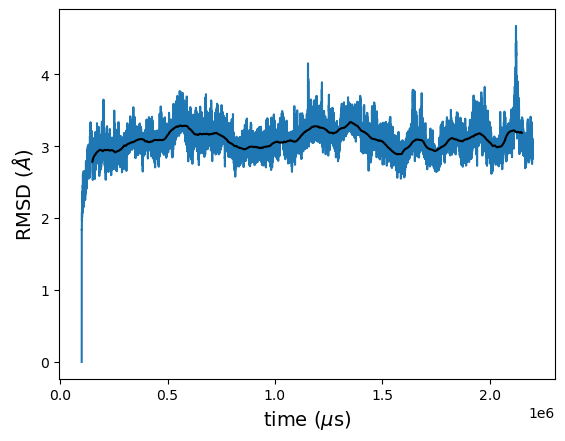

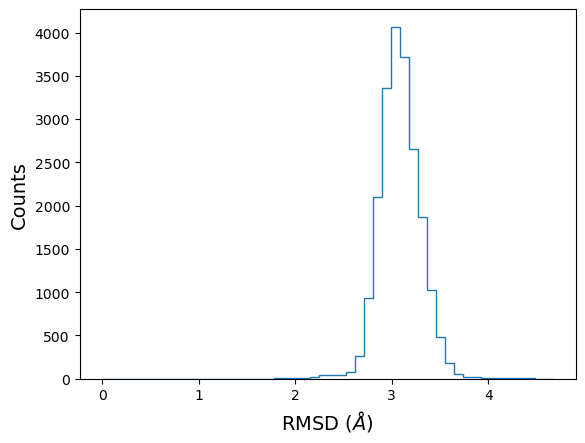

In [17]:
#Lets Calculate the RMSD and make a histogram from the starting structure 
def window_average(x, N):
    return np.convolve(x, np.ones(N)/N, mode='valid')

time=traj_protein.time
rmsd = md.rmsd(traj_protein, traj_protein, 0)

window_rmsd = window_average(rmsd*10, 1000)
window_time = window_average(time, 1000)

plt.plot(time,rmsd*10)
plt.plot(window_time,window_rmsd, c='k')
plt.ylabel('RMSD ($\AA$)',size=14);
plt.xlabel('time ($\mu$s)',size=14)
plt.show()
plt.clf()

plt.hist(rmsd*10,histtype='step',bins=50)
plt.ylabel('Counts',size=14);
plt.xlabel('RMSD ($\AA$)',size=14)
plt.show()

In [18]:
select_CA = traj_protein.topology.select('name CA')
select_BB = traj_protein.topology.select('backbone and not type H')
select_sidechains = traj_protein.topology.select('sidechain and not type H')
select_DBD = traj_protein.topology.select('resid 172 to 274')
select_cupin = traj_protein.topology.select('resid 1 to 88 or resid 113 to 122')
select_dimer_interface = traj_protein.topology.select('resid 90 to 103 or resid 123 to 153')
rmsd_CA = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_CA)
rmsd_BB = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_BB)
rmsd_sidechains = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_sidechains)
rmsd_DBD = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_DBD)
rmsd_cupin = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_cupin)
rmsd_dimer_interface = md.rmsd(traj_protein, traj_protein[0], atom_indices=select_dimer_interface)

<>:6: SyntaxWarning:

invalid escape sequence '\m'

<>:13: SyntaxWarning:

invalid escape sequence '\m'

<>:19: SyntaxWarning:

invalid escape sequence '\m'

<>:6: SyntaxWarning:

invalid escape sequence '\m'

<>:13: SyntaxWarning:

invalid escape sequence '\m'

<>:19: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/986410115.py:6: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/986410115.py:13: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/986410115.py:19: SyntaxWarning:

invalid escape sequence '\m'



Text(0.5, 1.0, 'Sidechains')

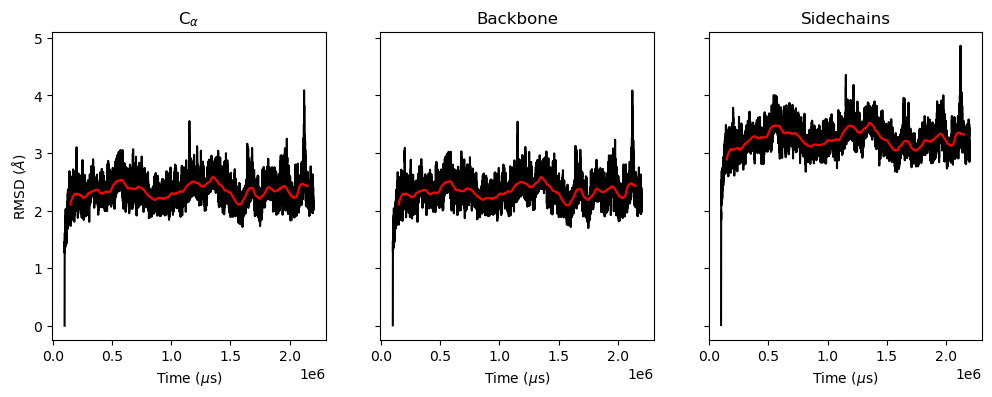

In [19]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))

# C Alphas 
ax[0].plot(time, rmsd_CA*10, c='k')
ax[0].plot(window_average(time, 1000), window_average(rmsd_CA*10,1000), c='r')
ax[0].set_xlabel('Time ($\mu$s)')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title(r'C$_\alpha$')

# Backbone
ax[1].plot(time, rmsd_BB*10, c='k')
ax[1].plot(window_average(time, 1000), window_average(rmsd_BB*10,1000), c='r')
ax[1].set_xlabel('Time ($\mu$s)')
ax[1].set_title('Backbone')

# Sidechains
ax[2].plot(time, rmsd_sidechains*10, c='k')
ax[2].plot(window_average(time, 1000), window_average(rmsd_sidechains*10,1000), c='r')
ax[2].set_xlabel('Time ($\mu$s)')
ax[2].set_title('Sidechains')

<>:6: SyntaxWarning:

invalid escape sequence '\m'

<>:13: SyntaxWarning:

invalid escape sequence '\m'

<>:19: SyntaxWarning:

invalid escape sequence '\m'

<>:6: SyntaxWarning:

invalid escape sequence '\m'

<>:13: SyntaxWarning:

invalid escape sequence '\m'

<>:19: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/472776165.py:6: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/472776165.py:13: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/472776165.py:19: SyntaxWarning:

invalid escape sequence '\m'



Text(0.5, 1.0, 'Dimerization Interface')

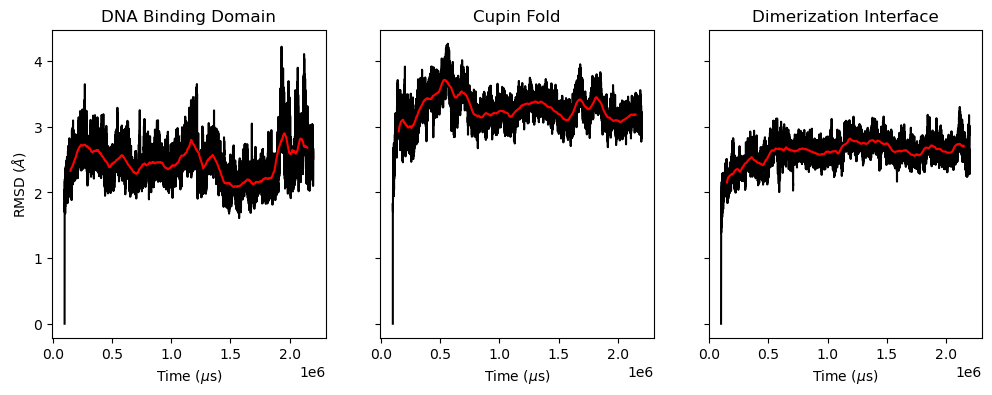

In [20]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))

# DNA Binding Domain 
ax[0].plot(time, rmsd_DBD*10, c='k')
ax[0].plot(window_average(time, 1000), window_average(rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Time ($\mu$s)')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time, rmsd_cupin*10, c='k')
ax[1].plot(window_average(time, 1000), window_average(rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Time ($\mu$s)')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time, rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time, 1000), window_average(rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Time ($\mu$s)')
ax[2].set_title('Dimerization Interface')

<>:9: SyntaxWarning:

invalid escape sequence '\m'

<>:9: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/852894860.py:9: SyntaxWarning:

invalid escape sequence '\m'



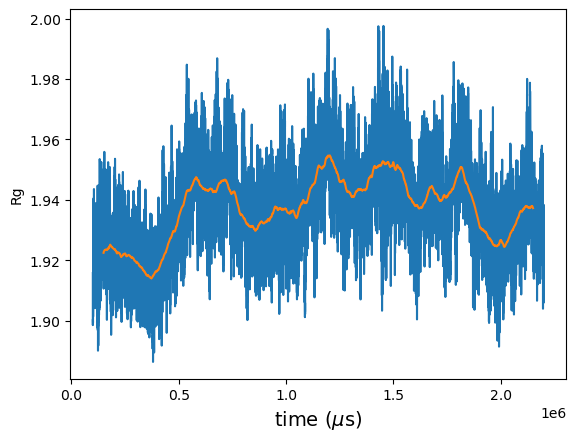

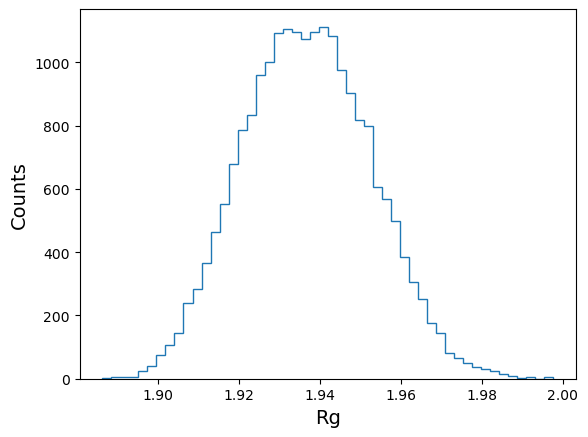

In [21]:
#Lets calculate the radius of gyration and make a histogram
rg=md.compute_rg(traj_protein, masses=None)

window_rg = window_average(rg, 1000)

plt.plot(time,rg)
plt.plot(window_time,window_rg)
plt.ylabel('Rg');
plt.xlabel('time ($\mu$s)',size=14)
plt.show()
plt.clf()

plt.hist(rg,histtype='step',bins=50)
plt.ylabel('Counts',size=14);
plt.xlabel('Rg',size=14)
plt.show()

In [22]:
#Lets identify subtantially populated hydrogen bonds
hbonds = md.baker_hubbard(traj_protein, periodic=False)
label = lambda hbond : '%s -- %s' % (traj_protein.topology.atom(hbond[0]), traj_protein.topology.atom(hbond[2]))
for hbond in hbonds:
    print(label(hbond))
    

ASN21-N -- ASN21-OD1
ASN21-N -- ASN21-OD1
ASN21-N -- ASN21-OD1
ASN22-N -- VAL76-O
ASN22-N -- LYS274-O
ASN22-ND2 -- LYS273-O
MET23-N -- ASN21-OD1
MET23-N -- ASN22-OD1
LEU24-N -- LEU74-O
LEU26-N -- VAL72-O
LYS28-N -- ASP71-OD1
LYS28-N -- ASP71-OD2
ILE29-N -- MET70-O
ARG30-N -- TYR225-OH
ARG30-NE -- ASP221-OD2
ARG30-NH1 -- ARG30-O
ARG30-NH1 -- ASN213-OD1
ARG30-NH1 -- ASP221-OD1
ARG30-NH1 -- ASP221-OD2
ARG30-NH2 -- ASP221-OD1
ARG30-NH2 -- ASP221-OD2
ARG30-NH2 -- ASN213-OD1
ARG30-NH2 -- ASP221-OD1
PHE31-N -- THR68-O
ASN33-ND2 -- CYS34-O
ASN33-ND2 -- GLU174-OE1
ALA35-N -- VAL64-O
ILE36-N -- TYR86-O
ILE37-N -- CYS62-O
HIS38-N -- GLU84-O
HIS38-NE2 -- THR127-OG1
LEU39-N -- SER60-O
ARG40-NE -- ASP41-OD1
ARG40-NE -- ASP41-OD2
ARG40-NH1 -- GLU124-OE1
ARG40-NH1 -- GLU124-OE2
ARG40-NH2 -- ASP41-OD1
ARG40-NH2 -- ASP41-OD2
ARG40-NH2 -- GLU124-OE1
ARG40-NH2 -- GLU124-OE2
GLN43-N -- LYS75-O
GLN43-NE2 -- ASN55-OD1
LEU44-N -- ILE56-O
LEU45-N -- ALA73-O
ILE46-N -- LEU54-O
ARG47-N -- ASP71-O
ARG47-NH1 -- TH

In [23]:
for hbond in hbonds:
 donor = top.atom(hbond[0])
 acc = top.atom(hbond[2])
 print(hbond,donor,acc)

[ 0  1 10] ASN21-N ASN21-OD1
[ 0  2 10] ASN21-N ASN21-OD1
[ 0  3 10] ASN21-N ASN21-OD1
[ 16  17 933] ASN22-N VAL76-O
[  16   17 4196] ASN22-N LYS274-O
[  25   26 4174] ASN22-ND2 LYS273-O
[30 31 10] MET23-N ASN21-OD1
[30 31 24] MET23-N ASN22-OD1
[ 47  48 895] LEU24-N LEU74-O
[ 82  83 866] LEU26-N VAL72-O
[123 124 847] LYS28-N ASP71-OD1
[123 124 848] LYS28-N ASP71-OD2
[145 146 838] ILE29-N MET70-O
[ 164  165 3386] ARG30-N TYR225-OH
[ 177  178 3310] ARG30-NE ASP221-OD2
[180 181 187] ARG30-NH1 ARG30-O
[ 180  182 3183] ARG30-NH1 ASN213-OD1
[ 180  182 3309] ARG30-NH1 ASP221-OD1
[ 180  182 3310] ARG30-NH1 ASP221-OD2
[ 183  184 3309] ARG30-NH2 ASP221-OD1
[ 183  184 3310] ARG30-NH2 ASP221-OD2
[ 183  185 3183] ARG30-NH2 ASN213-OD1
[ 183  185 3309] ARG30-NH2 ASP221-OD1
[188 189 805] PHE31-N THR68-O
[238 239 253] ASN33-ND2 CYS34-O
[ 238  239 2520] ASN33-ND2 GLU174-OE1
[254 255 740] ALA35-N VAL64-O
[ 264  265 1080] ILE36-N TYR86-O
[283 284 703] ILE37-N CYS62-O
[ 302  303 1043] HIS38-N GLU84-O
[ 313

In [24]:
# Hbond_index=4
# hbond=hbonds[Hbond_index]
# donor = top.atom(hbond[0])
# acc = top.atom(hbond[2])
# print(hbond,donor,acc)

# da_distance = md.compute_distances(trj, [[hbond[0],hbond[2]]], periodic=False)
# plt.hist(da_distance,histtype='step',bins=20, label=label(hbonds[Hbond_index]))
# #for i in [2, 3, 4]:
# #    plt.hist(da_distances[:, i], color=next(color),histtype='step',bins=10, label=label(hbonds[i]), alpha=0.5)
# plt.legend()
# plt.ylabel('Freq',size=14);
# plt.xlabel('Donor-acceptor distance [nm]',size=14)
# plt.show()

***We're going to run a Principle Component Analysis (PCA)***

This takes the variance of the cartesian coordinates of each atom over the course of the trajectory and finds "projections" that explain as much of variance as posisble.

https://en.wikipedia.org/wiki/Principal_component_analysis

In [25]:
idx_selector = np.triu_indices(len(select_CA), k=1)
idx_selector

(array([  0,   0,   0, ..., 251, 251, 252], shape=(32131,)),
 array([  1,   2,   3, ..., 252, 253, 253], shape=(32131,)))

In [26]:
CA_pairs = np.stack([select_CA[idx_selector[0].tolist()], select_CA[idx_selector[1].tolist()]]).T

In [27]:
Ca_distances = md.compute_distances(traj_protein, CA_pairs, periodic=True)

In [28]:
# Ca PCA
pca_ca = PCA(n_components=2)
pca_ca.fit(Ca_distances)
Ca_distances_pca = pca_ca.transform(Ca_distances)
print(Ca_distances_pca.shape)

# Cartesian PCA
pca1 = PCA(n_components=2)
traj_protein.superpose(traj_protein, 0)
reduced_cartesian = pca1.fit_transform(traj_protein.xyz.reshape(traj_protein.n_frames, traj_protein.n_atoms * 3))
print(reduced_cartesian.shape)

(21001, 2)
(21001, 2)


<>:18: SyntaxWarning:

invalid escape sequence '\m'

<>:18: SyntaxWarning:

invalid escape sequence '\m'

/tmp/ipykernel_22007/456197298.py:18: SyntaxWarning:

invalid escape sequence '\m'



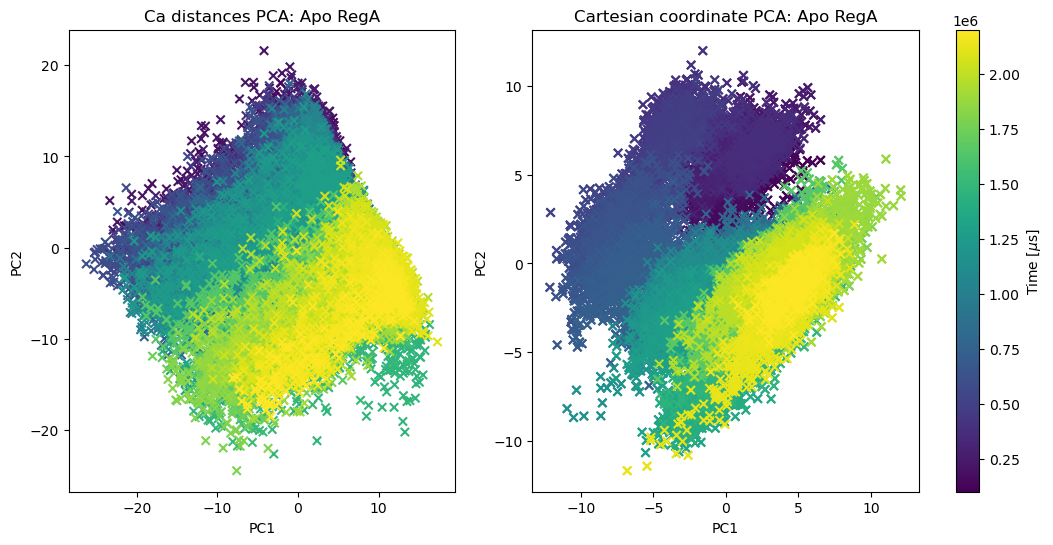

In [29]:
#We Can plot each frame as a function of the values of each PC(principal component): PC1 and PC2

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].scatter(Ca_distances_pca[:, 0], Ca_distances_pca[:,1], marker='x', c=time)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2') 
ax[0].set_title('Ca distances PCA: Apo RegA')

ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=time)
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2') 
ax[1].set_title('Cartesian coordinate PCA: Apo RegA')

# Add colorbar for the right scatter plot (ax[1])
sc = ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=time)
cbar = plt.colorbar(sc, ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('Time [$\mu$s]')

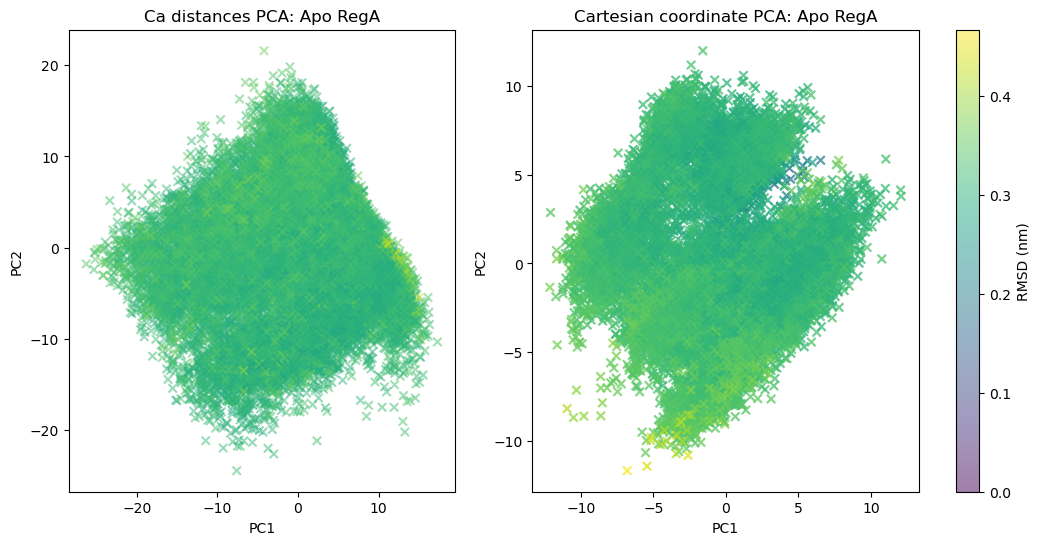

In [30]:
#We Can plot each frame as a function of the values of each PC(principal component): PC1 and PC2

fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[0].scatter(Ca_distances_pca[:, 0], Ca_distances_pca[:,1], marker='x', c=rmsd, alpha=0.5)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2') 
ax[0].set_title('Ca distances PCA: Apo RegA')

ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=rmsd, alpha=0.5)
ax[1].set_xlabel('PC1')
ax[1].set_ylabel('PC2') 
ax[1].set_title('Cartesian coordinate PCA: Apo RegA')

# Add colorbar for the right scatter plot (ax[1])
sc = ax[1].scatter(reduced_cartesian[:, 0], reduced_cartesian[:,1], marker='x', c=rmsd, alpha=0.5)
cbar = plt.colorbar(sc, ax=ax.ravel().tolist(), fraction=0.046, pad=0.04)
cbar.set_label('RMSD (nm)')


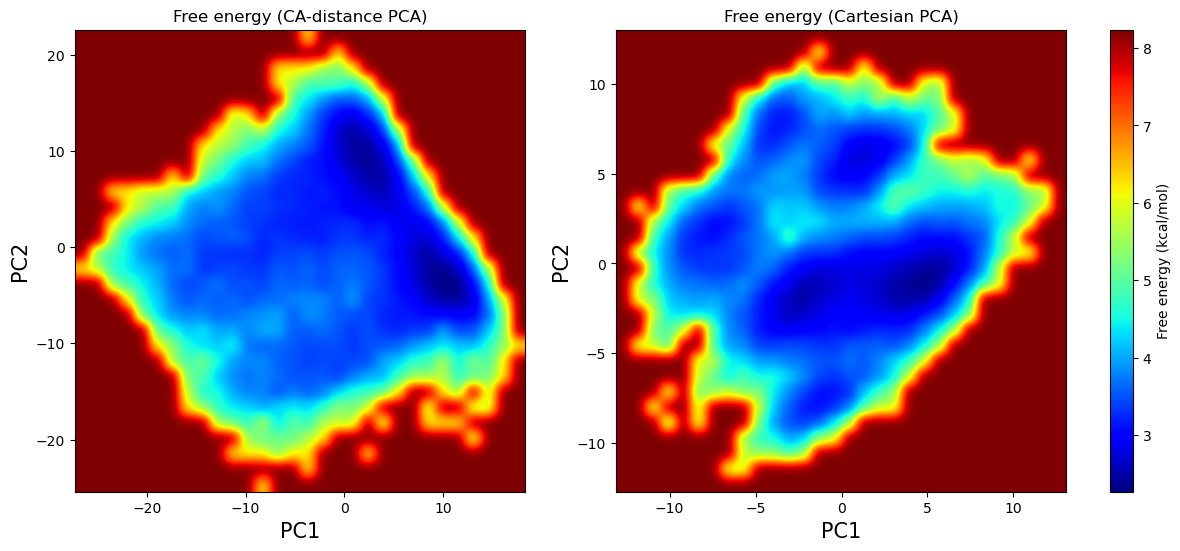

In [31]:
# Free energy plots for both CA-distance PCA and Cartesian PCA (side-by-side).
# This cell relies on variables computed in other cells:
# - Ca_distances_pca (from CA distances PCA)
# - reduced_cartesian (from Cartesian PCA)
# If the free_energy helper isn't defined yet (it exists in later cells), define a small fallback.

if 'free_energy' not in globals():
    def free_energy(a, b, T, y0, ymax, x0, xmax):
        free_energy, xedges, yedges = np.histogram2d(
            a, b, 30, [[y0, ymax], [x0, xmax]], density=True, weights=None)
        free_energy = np.log(np.flipud(free_energy) + 1e-6)
        free_energy = -(0.001987 * T) * free_energy
        return free_energy, xedges, yedges

# Prepare PC pairs
PC1_ca, PC2_ca = Ca_distances_pca[:, 0], Ca_distances_pca[:, 1]
PC1_cart, PC2_cart = reduced_cartesian[:, 0], reduced_cartesian[:, 1]

# Set ranges with a small margin
def _range(v, margin=1.0):
    mn, mx = np.min(v), np.max(v)
    return mn - margin, mx + margin

y0_ca, ymax_ca = _range(PC2_ca)
x0_ca, xmax_ca = _range(PC1_ca)

y0_cart, ymax_cart = _range(PC2_cart)
x0_cart, xmax_cart = _range(PC1_cart)

# Compute free energies
dG_ca, xedges_ca, yedges_ca = free_energy(PC2_ca, PC1_ca, 300, y0_ca, ymax_ca, x0_ca, xmax_ca)
dG_cart, xedges_cart, yedges_cart = free_energy(PC2_cart, PC1_cart, 300, y0_cart, ymax_cart, x0_cart, xmax_cart)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(dG_ca, interpolation='gaussian',
                     extent=[yedges_ca[0], yedges_ca[-1], xedges_ca[0], xedges_ca[-1]],
                     cmap='jet', aspect='auto')
axes[0].set_title('Free energy (CA-distance PCA)')
axes[0].set_xlabel('PC1', size = 15)
axes[0].set_ylabel('PC2', size = 15)
axes[0].set_xlim(np.min(PC1_ca)-1, np.max(PC1_ca)+1)
axes[0].set_ylim(np.min(PC2_ca)-1, np.max(PC2_ca)+1)

im1 = axes[1].imshow(dG_cart, interpolation='gaussian',
                     extent=[yedges_cart[0], yedges_cart[-1], xedges_cart[0], xedges_cart[-1]],
                     cmap='jet', aspect='auto')
axes[1].set_title('Free energy (Cartesian PCA)')
axes[1].set_xlabel('PC1', size = 15)
axes[1].set_ylabel('PC2', size = 15)
axes[1].set_xlim(np.min(PC1_cart)-1, np.max(PC1_cart)+1)
axes[1].set_ylim(np.min(PC2_cart)-1, np.max(PC2_cart)+1)

# Shared colorbar
cbar = plt.colorbar(im1, ax=axes.ravel().tolist(), location='right', fraction=0.046, pad=0.04)
cbar.set_label('Free energy (kcal/mol)')

In [32]:
# Identify the bins with the lowest free energy in the CA-distance PCA plot
min_dG_ca = np.nanmin(dG_ca)
low_energy_threshold = min_dG_ca + 1.0  # within 1 kcal/mol of the minimum

# Find bin indices where free energy is within threshold
low_energy_bins = np.where(dG_ca <= low_energy_threshold)

# Convert bin indices to PC1/PC2 ranges
PC1_ca_centers = 0.5 * (yedges_ca[:-1] + yedges_ca[1:])
PC2_ca_centers = 0.5 * (xedges_ca[:-1] + xedges_ca[1:])

# Get all (PC1, PC2) centers for low energy bins
low_energy_coords = [(PC1_ca_centers[j], PC2_ca_centers[i]) for i, j in zip(*low_energy_bins)]

# Find frames whose (PC1, PC2) values fall within the low energy bins
frames_in_low_energy = []
for i, (pc1, pc2) in enumerate(zip(PC1_ca, PC2_ca)):
    # Find the bin index for this frame
    idx1 = np.digitize(pc1, yedges_ca) - 1
    idx2 = np.digitize(pc2, xedges_ca) - 1
    if (idx1, idx2) in zip(*low_energy_bins):
        frames_in_low_energy.append(i)

frames_in_low_energy = np.array(frames_in_low_energy)
print("Number of frames in lowest free energy CA-distance PCA basin:", len(frames_in_low_energy))

Number of frames in lowest free energy CA-distance PCA basin: 7811


In [30]:
# Frames which correlate to the low free energy basin in the PC1 vs. PC2 plot.

basin1frames = np.where((PC1>-5) & (PC1<0) & (PC2>-4) & (PC2<0))
basin1frames = basin1frames[0]
print("Number of frames in basin 1:",len(basin1frames))

basin2frames = np.where((PC1>1) & (PC1<7) & (PC2>-4) & (PC2<1))
basin2frames = basin2frames[0]
print("Number of frames in basin 2:",len(basin2frames))

basin3frames = np.where((PC1>-1) & (PC1<2) & (PC2>4) & (PC2<7))
basin3frames = basin3frames[0]
print("Number of frames in basin 3:",len(basin3frames))

basin1trajectory = traj_protein[basin1frames]
basin1trajectory.save_xtc(f'/data/Jayde/Rega/Apo/Basin_1.xtc')

basin2trajectory = traj_protein[basin2frames]
basin2trajectory.save_xtc(f'/data/Jayde/Rega/Apo/Basin_2.xtc')

basin3trajectory = traj_protein[basin3frames]
basin3trajectory.save_xtc(f'/data/Jayde/Rega/Apo/Basin_3.xtc')

Number of frames in basin 1: 3621
Number of frames in basin 2: 5940
Number of frames in basin 3: 1298


In [31]:
Hprop_basin1,Eprop_basin1=dssp_convert(dssp[basin1frames])
Hprop_basin2,Eprop_basin2=dssp_convert(dssp[basin2frames])
Hprop_basin3,Eprop_basin3=dssp_convert(dssp[basin3frames])

fig = go.Figure()
fig.add_trace(go.Scatter(x=residue_num, y=Hprop_basin1, mode='lines', name='basin1 helix', line=dict(color='red')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop_basin1, mode='lines', name='basin1 sheet', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=residue_num, y=Hprop_basin2, mode='lines', name='basin2 helix', line=dict(color='green')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop_basin2, mode='lines', name='basin2 sheet', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=residue_num, y=Hprop_basin3, mode='lines', name='basin3 helix', line=dict(color='purple')))
fig.add_trace(go.Scatter(x=residue_num, y=Eprop_basin3, mode='lines', name='basin3 sheet', line=dict(color='pink')))
fig.update_layout(title='Secondary Structure Fractions per Basin',
                  xaxis_title='Residue',
                  yaxis_title='Secondary Structure Fraction',
                  legend=dict(x=0, y=1))

In [40]:
atom_indices = [a.index for a in traj_protein.topology.atoms if a.element.symbol != 'H']
distances = np.empty((basin1trajectory.n_frames, basin1trajectory.n_frames))
for i in range(basin1trajectory.n_frames):
    distances[i] = md.rmsd(basin1trajectory, basin1trajectory, i, atom_indices=atom_indices)

distances_basin2 = np.empty((basin2trajectory.n_frames, basin2trajectory.n_frames))
for i in range(basin2trajectory.n_frames):
    distances_basin2[i] = md.rmsd(basin2trajectory, basin2trajectory, i, atom_indices=atom_indices)

distances_basin3 = np.empty((basin3trajectory.n_frames, basin3trajectory.n_frames))
for i in range(basin3trajectory.n_frames):
    distances_basin3[i] = md.rmsd(basin3trajectory, basin3trajectory, i, atom_indices=atom_indices)

beta = 1
index = np.exp(-beta*distances / distances.std()).sum(axis=1).argmax()
print(index)

index2 = np.exp(-beta*distances_basin2 / distances_basin2.std()).sum(axis=1).argmax()
print(index2)

index3 = np.exp(-beta*distances_basin3 / distances_basin3.std()).sum(axis=1).argmax()
print(index3)

centroid1 = basin1trajectory[index]
centroid1.save_pdb(f'/data/Jayde/Rega/Apo/Basin_1_centroid.pdb')
print(centroid1)

centroid2 = basin2trajectory[index2]
centroid2.save_pdb(f'/data/Jayde/Rega/Apo/Basin_2_centroid.pdb')
print(centroid2)

centroid3 = basin3trajectory[index3]
centroid3.save_pdb(f'/data/Jayde/Rega/Apo/Basin_3_centroid.pdb')
print(centroid3)

1867
5045
854
<mdtraj.Trajectory with 1 frames, 4198 atoms, 254 residues, and unitcells>
<mdtraj.Trajectory with 1 frames, 4198 atoms, 254 residues, and unitcells>
<mdtraj.Trajectory with 1 frames, 4198 atoms, 254 residues, and unitcells>


In [34]:
crystal_structure = md.load_pdb('/data/Jayde/Rega/RegAChainB.pdb')
traj_basin1 = md.load('/data/Jayde/Rega/Apo/Basin_1.xtc', top='/data/Jayde/Rega/Apo/Basin_1_centroid.pdb',stride=1)

crystal_indices = crystal_structure.topology.select('name CA')
crystal_structure_CA = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('backbone and not type H')
crystal_structure_BB = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('residue 0 to 252 and sidechain and not type H')
crystal_structure_sidechains = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('residue 172 to 273 and not water and not type H')
crystal_structure_DBD = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('(residue 1 to 88 or residue 113 to 122) and not water and not type H')
crystal_structure_cupin = crystal_structure.atom_slice(crystal_indices)
crystal_indices = crystal_structure.topology.select('(residue 90 to 103 or residue 123 to 153) and not water and not type H')
crystal_structure_dimer_interface = crystal_structure.atom_slice(crystal_indices)

basin1_select_CA = traj_basin1.topology.select('name CA and not type H')
basin1_select_BB = traj_basin1.topology.select('backbone and not type H')
basin1_select_sidechains = traj_basin1.topology.select('residue 0 to 252 and sidechain and not type H')
basin1_select_DBD = traj_basin1.topology.select('residue 172 to 273 and not type H and not water')
basin1_select_cupin = traj_basin1.topology.select('(residue 1 to 88 or residue 113 to 122) and not type H and not water')
basin1_select_dimer_interface = traj_basin1.topology.select('(residue 90 to 103 or residue 123 to 153) and not type H and not water')
basin1_rmsd_CA = md.rmsd(traj_basin1.atom_slice(basin1_select_CA), crystal_structure_CA)
basin1_rmsd_BB = md.rmsd(traj_basin1.atom_slice(basin1_select_BB), crystal_structure_BB)
basin1_rmsd_sidechains = md.rmsd(traj_basin1.atom_slice(basin1_select_sidechains), crystal_structure_sidechains)
basin1_rmsd_DBD = md.rmsd(traj_basin1.atom_slice(basin1_select_DBD), crystal_structure_DBD)
basin1_rmsd_cupin = md.rmsd(traj_basin1.atom_slice(basin1_select_cupin), crystal_structure_cupin)
basin1_rmsd_dimer_interface = md.rmsd(traj_basin1.atom_slice(basin1_select_dimer_interface), crystal_structure_dimer_interface)

In [35]:
traj_basin2 = md.load('/data/Jayde/Rega/Apo/Basin_2.xtc', top='/data/Jayde/Rega/Apo/Basin_2_centroid.pdb',stride=1)

basin2_select_CA = traj_basin2.topology.select('name CA and not type H')
basin2_select_BB = traj_basin2.topology.select('backbone and not type H')
basin2_select_sidechains = traj_basin2.topology.select('residue 0 to 252 and sidechain and not type H')
basin2_select_DBD = traj_basin2.topology.select('residue 172 to 273 and not type H and not water')
basin2_select_cupin = traj_basin2.topology.select('(residue 1 to 88 or residue 113 to 122) and not type H and not water')
basin2_select_dimer_interface = traj_basin2.topology.select('(residue 90 to 103 or residue 123 to 153) and not type H and not water')
basin2_rmsd_CA = md.rmsd(traj_basin2.atom_slice(basin2_select_CA), crystal_structure_CA)
basin2_rmsd_BB = md.rmsd(traj_basin2.atom_slice(basin2_select_BB), crystal_structure_BB)
basin2_rmsd_sidechains = md.rmsd(traj_basin2.atom_slice(basin2_select_sidechains), crystal_structure_sidechains)
basin2_rmsd_DBD = md.rmsd(traj_basin2.atom_slice(basin2_select_DBD), crystal_structure_DBD)
basin2_rmsd_cupin = md.rmsd(traj_basin2.atom_slice(basin2_select_cupin), crystal_structure_cupin)
basin2_rmsd_dimer_interface = md.rmsd(traj_basin2.atom_slice(basin2_select_dimer_interface), crystal_structure_dimer_interface)

In [36]:
traj_basin3 = md.load('/data/Jayde/Rega/Apo/Basin_3.xtc', top='/data/Jayde/Rega/Apo/Basin_3_centroid.pdb',stride=1)

basin3_select_CA = traj_basin3.topology.select('name CA and not type H')
basin3_select_BB = traj_basin3.topology.select('backbone and not type H')
basin3_select_sidechains = traj_basin3.topology.select('residue 0 to 252 and sidechain and not type H')
basin3_select_DBD = traj_basin3.topology.select('residue 172 to 273 and not type H and not water')
basin3_select_cupin = traj_basin3.topology.select('(residue 1 to 88 or residue 113 to 122) and not type H and not water')
basin3_select_dimer_interface = traj_basin3.topology.select('(residue 90 to 103 or residue 123 to 153) and not type H and not water')
basin3_rmsd_CA = md.rmsd(traj_basin3.atom_slice(basin3_select_CA), crystal_structure_CA)
basin3_rmsd_BB = md.rmsd(traj_basin3.atom_slice(basin3_select_BB), crystal_structure_BB)
basin3_rmsd_sidechains = md.rmsd(traj_basin3.atom_slice(basin3_select_sidechains), crystal_structure_sidechains)
basin3_rmsd_DBD = md.rmsd(traj_basin3.atom_slice(basin3_select_DBD), crystal_structure_DBD)
basin3_rmsd_cupin = md.rmsd(traj_basin3.atom_slice(basin3_select_cupin), crystal_structure_cupin)
basin3_rmsd_dimer_interface = md.rmsd(traj_basin3.atom_slice(basin3_select_dimer_interface), crystal_structure_dimer_interface)

Text(0.5, 1.0, 'Dimerization Interface')

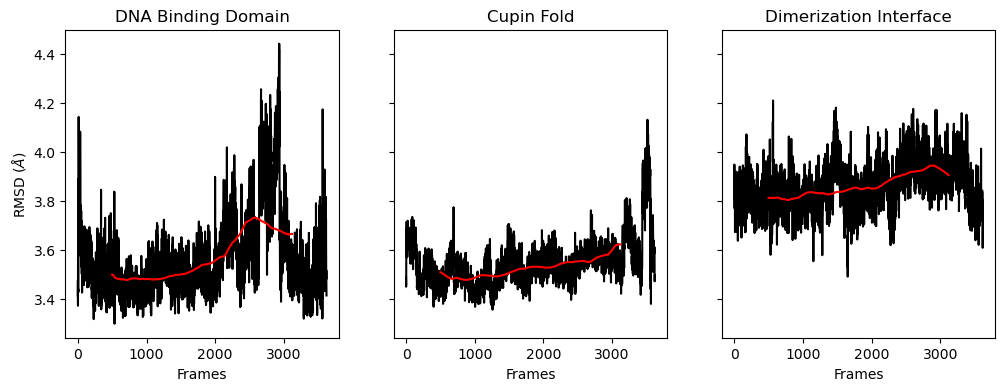

In [37]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))
time_basin1 = np.arange(0, traj_basin1.n_frames)

# DNA Binding Domain 
ax[0].plot(time_basin1, basin1_rmsd_DBD*10, c='k')
ax[0].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Frames')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time_basin1, basin1_rmsd_cupin*10, c='k')
ax[1].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Frames')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time_basin1, basin1_rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time_basin1, 1000), window_average(basin1_rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Frames')
ax[2].set_title('Dimerization Interface')

Text(0.5, 1.0, 'Dimerization Interface')

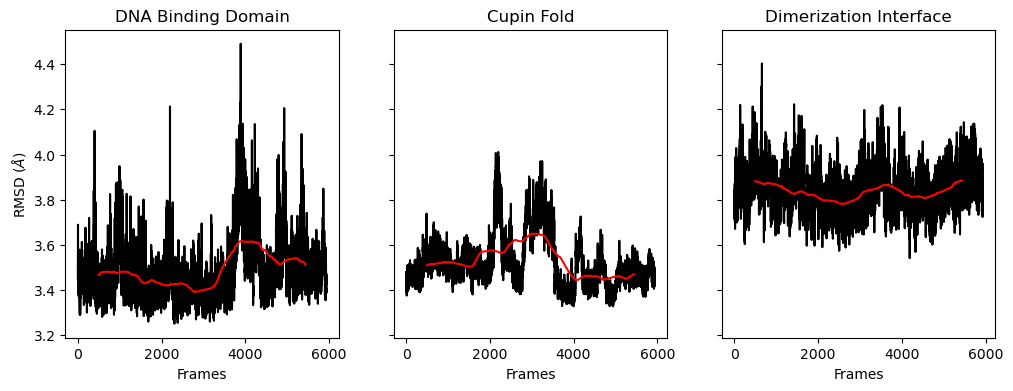

In [38]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))
time_basin2 = np.arange(0, traj_basin2.n_frames)

# DNA Binding Domain 
ax[0].plot(time_basin2, basin2_rmsd_DBD*10, c='k')
ax[0].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Frames')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time_basin2, basin2_rmsd_cupin*10, c='k')
ax[1].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Frames')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time_basin2, basin2_rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time_basin2, 1000), window_average(basin2_rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Frames')
ax[2].set_title('Dimerization Interface')

Text(0.5, 1.0, 'Dimerization Interface')

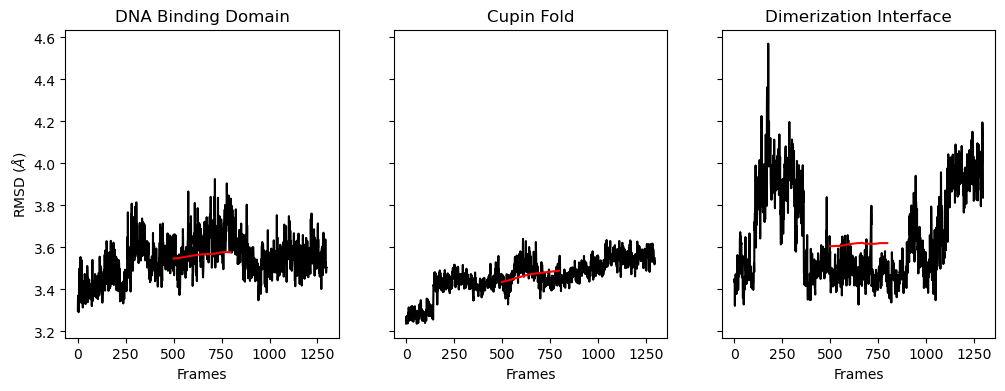

In [39]:
fig, ax = plt.subplots(1,3, sharey=True, figsize=(12,4))
time_basin3 = np.arange(0, traj_basin3.n_frames)

# DNA Binding Domain 
ax[0].plot(time_basin3, basin3_rmsd_DBD*10, c='k')
ax[0].plot(window_average(time_basin3, 1000), window_average(basin3_rmsd_DBD*10,1000), c='r')
ax[0].set_xlabel('Frames')
ax[0].set_ylabel(r'RMSD ($\AA$)')
ax[0].set_title('DNA Binding Domain')

# Cupin Fold
ax[1].plot(time_basin3, basin3_rmsd_cupin*10, c='k')
ax[1].plot(window_average(time_basin3, 1000), window_average(basin3_rmsd_cupin*10,1000), c='r')
ax[1].set_xlabel('Frames')
ax[1].set_title('Cupin Fold')

# Dimerization Interface
ax[2].plot(time_basin3, basin3_rmsd_dimer_interface*10, c='k')
ax[2].plot(window_average(time_basin3, 1000), window_average(basin3_rmsd_dimer_interface*10,1000), c='r')
ax[2].set_xlabel('Frames')
ax[2].set_title('Dimerization Interface')

In [ ]:
#Lets Calculate Some Correlation Times of Some Dihedral angles.
def autocorr1(x,lags):
    '''numpy.corrcoef, partial'''
    corr=[1. if l==0 else np.corrcoef(x[l:],x[:-l])[0][1] for l in lags]
    return np.array(corr)

#time in microseconds
time=np.linspace(0,1000,traj_protein.n_frames)


lags=range(10)
#C1C2bondlength[:,0]
phi2_acf=autocorr1(dihedral_dict['phi'][2],lags)
phi20_acf=autocorr1(dihedral_dict['phi'][20],lags)
chi20_acf=autocorr1(dihedral_dict['chi1'][20],lags)

plt.plot(time[lags],phi2_acf,color='b',label='phi_2')
plt.plot(time[lags],phi20_acf,color='r',label='phi_20')
plt.plot(time[lags],chi20_acf,color='g',label='chi1_20')

plt.legend()
plt.xlabel("Time ($\mu$s)", size=14, labelpad=15)
plt.ylabel("Autocorrelation", size=14, labelpad=15)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xticks(size='14')
plt.yticks(size='14')
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_394902/1272716057.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Time ($\mu$s)", size=14, labelpad=15)
/tmp/ipykernel_394902/1272716057.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Time ($\mu$s)", size=14, labelpad=15)


KeyError: 2

In [ ]:

def contact_map_avg(traj_protein, prot_len, cutoff=1.2):
    """
    Create average contact and distance maps for entire trajectory.
    Diagonal and self-distances are set to 0.
    
    :param trj: md.Trajectory object
    :param prot_len: number of residues
    :param cutoff: contact distance threshold in nm
    :return: (contact_map, distance_map) as (prot_len x prot_len) numpy arrays
    """
    # Generate unique residue pairs (i < j)
    pairs = [[i, j] for i in range(prot_len) for j in range(i+1, prot_len)]
    
    # Compute distances for all pairs across trajectory
    distances, _ = md.compute_contacts(traj_protein, pairs)
    
    # Initialize output matrices
    contact_map = np.zeros((prot_len, prot_len), dtype=float)
    distance_map = np.zeros((prot_len, prot_len), dtype=float)
    
    # Fill in values symmetrically
    for idx, (i, j) in enumerate(pairs):
        dist_ij = distances[:, idx]
        contact_ij = (dist_ij < cutoff).astype(int)

        if i==j:
            # Set diagonal and self-distances to 0
            contact_ij.fill(0)
            dist_ij.fill(0.0)

        avg_contact = np.mean(contact_ij)
        avg_distance = np.mean(dist_ij)

        contact_map[i, j] = contact_map[j, i] = avg_contact
        distance_map[i, j] = distance_map[j, i] = avg_distance

    return contact_map, distance_map
contact_map, distance_map = contact_map_avg(traj_protein[::5], prot_len=traj_protein.n_residues, cutoff=0.8)



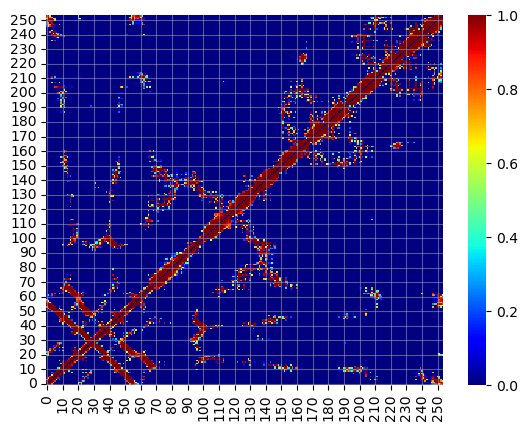

In [ ]:
ax = sns.heatmap(contact_map, vmin=0.0, vmax=1.0,cmap='jet')
ax.invert_yaxis()
ax.grid(which='both', alpha=0.5)


In [ ]:
# how to cluster 

from sklearn.cluster import KMeans

data = reduced_cartesian # or PCs of shape (n_frames, 2) 
n_clusters = 3 
kmeans = KMeans(n_clusters=n_clusters, n_init=10)
kmeans.fit(data)
labels = kmeans.labels_
np.savetxt("kmeans_labels.txt", labels)

In [ ]:
kmeans.cluster_centers_

array([[ 3.9019907 , -0.8408355 ],
       [-0.75534254,  6.0567794 ],
       [-3.526097  , -2.308712  ]], dtype=float32)

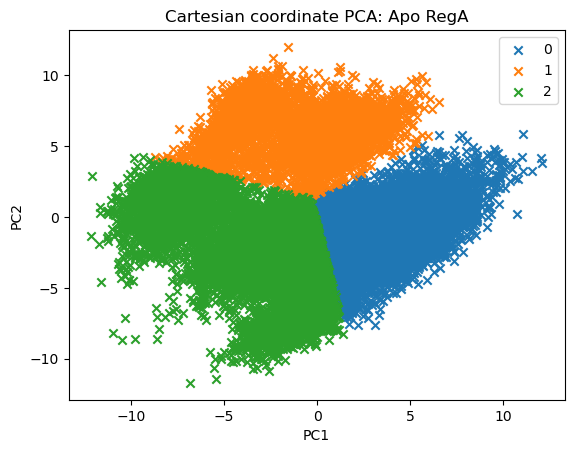

In [ ]:
plt.figure()
for i in np.unique(labels):
    plt.scatter(reduced_cartesian[:, 0][labels==i], reduced_cartesian[:,1][labels==i], marker='x', label=str(i))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Cartesian coordinate PCA: Apo RegA')
plt.legend()